# Linear Regression and PCA with PyTorch

## PyTorch beyond neural networks

PyTorch is widely known as a deep learning framework, but at its core it is a **high-performance tensor computation library** with GPU acceleration and a rich set of numerical routines. This makes it a practical tool for many engineering and scientific problems that have nothing to do with neural networks:

- **Curve fitting and regression** — fitting models to experimental data, sensor calibration, trend analysis in time series (`linalg.lstsq`, `polyval`)
- **Dimensionality reduction** — compressing high-dimensional measurements (e.g. vibration spectra, hyperspectral images) to a few dominant modes (`linalg.eigh`, `linalg.svd`)
- **Solving linear systems** — structural analysis (stiffness matrices), circuit simulation, heat transfer problems (`linalg.solve`, `linalg.lu`)
- **Eigenvalue problems** — modal analysis of mechanical structures, stability analysis of control systems (`linalg.eig`, `linalg.eigh`)
- **Signal processing** — spectral analysis, filtering, convolution of measurement data (`fft`, `conv1d`)
- **Optimisation** — parameter estimation, inverse problems, optimal control via automatic differentiation (`autograd`)

All of these benefit from **GPU acceleration** when the problem size grows — the same code runs on CPU or GPU by simply changing the target device.

This notebook demonstrates two of these problems: **linear regression** (least-squares curve fitting) and **PCA** (principal component analysis for dimensionality reduction), including CPU vs GPU performance comparisons.

**Prerequisites:** familiarity with tensors, arithmetic, broadcasting, and matrix multiplication (see *Introduction to PyTorch Tensors*).

In [1]:
import torch
import time
import sys
import os
import numpy as np
sys.path.insert(0, os.path.abspath('../src'))

from regression_viz import (
    plot_regression, plot_pca, plot_benchmark 
)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 1.13.1


---
## 0. Device Detection

PyTorch supports several GPU backends:

| Backend | Vendor | `torch.device` |
|---|---|---|
| CUDA | NVIDIA | `"cuda"` |
| ROCm | AMD | `"cuda"` (via HIP compatibility layer) |
| XPU | Intel | `"xpu"` |

The helper below detects the best available device so the rest of the notebook works on any hardware.

In [2]:
def get_device():
    """Return the best available accelerator, or CPU as fallback."""
    if torch.cuda.is_available():          # NVIDIA CUDA or AMD ROCm
        return torch.device("cuda")
    if hasattr(torch, "xpu") and torch.xpu.is_available():  # Intel XPU
        return torch.device("xpu")
    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
elif device.type == "xpu":
    print(f"GPU name: {torch.xpu.get_device_name(0)}")

Using device: cuda
GPU name: NVIDIA A100-SXM4-40GB


We also need a small helper to synchronise the GPU before timing, since GPU operations are asynchronous — the CPU call returns immediately while the GPU is still computing.

In [3]:
def sync(dev):
    """Wait for all pending operations on *dev* to finish."""
    if dev.type == "cuda":
        torch.cuda.synchronize()
    elif dev.type == "xpu":
        torch.xpu.synchronize()

---
## 1. Linear Regression

### Problem

Given a set of observations $(x_n, y_n),\; n = 1, \dots, N$, find the coefficients $a$ and $b$ of the line $f(x) = ax + b$ that **minimises the mean squared error**:

$$
\text{MSE} = \frac{1}{N} \sum_{n=1}^{N} (a x_n + b - y_n)^2
$$

### Matrix formulation

We can rewrite this as an over-determined system of linear equations:

$$
\underbrace{\begin{pmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_N & 1
\end{pmatrix}}_{X}
\underbrace{\begin{pmatrix}
a \\
b
\end{pmatrix}}_{\boldsymbol{\alpha}}
=
\underbrace{\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_N
\end{pmatrix}}_{\mathbf{y}}
$$

PyTorch's `torch.linalg.lstsq` finds the least-squares solution $\boldsymbol{\alpha}$ that minimises $\|X \boldsymbol{\alpha} - \mathbf{y}\|^2$.

### Example data

The dataset contains pairs of *(patient age, systolic blood pressure)* measurements.

In [4]:
data = [(39, 144), (47, 220), (45, 138), (47, 145), (65, 162), (46, 142),
        (67, 170), (42, 124), (67, 158), (56, 154), (64, 162), (56, 150),
        (59, 140), (34, 110), (42, 128)]

x_vals, y_vals = zip(*data)
print(f"{len(data)} observations")
print(f"Age range:      {min(x_vals)} – {max(x_vals)}")
print(f"Pressure range: {min(y_vals)} – {max(y_vals)}")

15 observations
Age range:      34 – 67
Pressure range: 110 – 220


### Solution

In [5]:
n = len(data)

# Build the design matrix X (N x 2) and target vector y (N,)
X = torch.ones((n, 2))
X[:, 0] = torch.tensor(x_vals, dtype=torch.float32)

y = torch.tensor(y_vals, dtype=torch.float32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: torch.Size([15, 2])
y shape: torch.Size([15])


In [6]:
# Solve the least-squares problem
alpha = torch.linalg.lstsq(X, y).solution

a = alpha[0].item()
b = alpha[1].item()
print(f"Regression line: f(x) = {a:.4f} * x + {b:.4f}")

Regression line: f(x) = 1.0474 * x + 95.6125


In [7]:
# Compute predictions and MSE
y_pred = X @ alpha
mse = ((y_pred - y) ** 2).mean()
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 464.21


### Visualisation

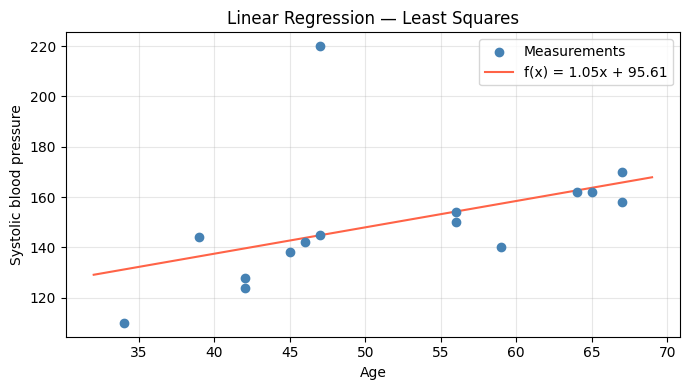

In [8]:
plot_regression(x_vals, y_vals, a, b)

### Performance: CPU vs GPU

With only 15 data points the computation is trivial. To see a meaningful difference we scale the problem up — generating a large synthetic dataset and timing `lstsq` on both devices.

In [9]:
def benchmark_lstsq(n_samples, dev, n_runs=10):
    """Time lstsq on *dev* and return the median wall-clock time in seconds."""
    torch.manual_seed(0)
    X_bench = torch.ones(n_samples, 2, device=dev)
    X_bench[:, 0] = torch.randn(n_samples, device=dev)
    y_bench = torch.randn(n_samples, device=dev)

    # Warm-up
    torch.linalg.lstsq(X_bench, y_bench)
    sync(dev)

    times = []
    for _ in range(n_runs):
        sync(dev)
        t0 = time.perf_counter()
        torch.linalg.lstsq(X_bench, y_bench)
        sync(dev)
        times.append(time.perf_counter() - t0)

    return float(np.median(times))

In [10]:
sizes = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]

cpu_dev = torch.device("cpu")
gpu_dev = device  # best available from section 0

cpu_times = [benchmark_lstsq(s, cpu_dev) for s in sizes]

if gpu_dev.type != "cpu":
    gpu_times = [benchmark_lstsq(s, gpu_dev) for s in sizes]
else:
    gpu_times = None
    print("No GPU available — skipping GPU benchmark.")

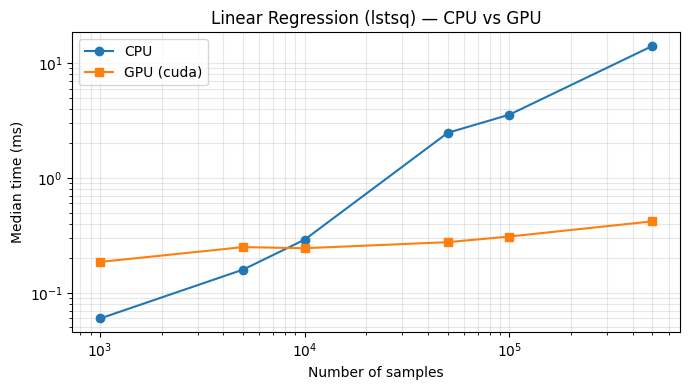

Speedup (CPU / GPU):
  n=  1,000:    0.32x
  n=  5,000:    0.64x
  n= 10,000:    1.19x
  n= 50,000:    8.95x
  n=100,000:   11.49x
  n=500,000:   33.62x


In [11]:
plot_benchmark(sizes, cpu_times, gpu_times, gpu_dev.type,
               "Linear Regression (lstsq) — CPU vs GPU")

---
## 2. Excercise 3: Principal Component Analysis (PCA)

### Idea

PCA finds the directions (principal components) along which the data varies the most. Given an $N \times D$ data matrix:

1. **Centre** the data by subtracting the per-column mean.
2. Compute the **covariance matrix**: $\;C = \frac{1}{N-1} X_c^T X_c$
3. Find the **eigenvalues and eigenvectors** of $C$. The eigenvectors are the principal components; the eigenvalues measure variance along each direction.

Because the covariance matrix is symmetric and positive semi-definite, we use `torch.linalg.eigh` (optimised for symmetric/Hermitian matrices) instead of the general `eig`.

### Generate synthetic data

We create 2D data with strong correlation — an elliptical cloud tilted away from the axes.

In [12]:
torch.manual_seed(42)
np.random.seed(42)

num_samples = 1000
mean = [5.0, 10.0]
cov = [[3.0, 2.0],
       [2.0, 2.0]]

data_np = np.random.multivariate_normal(mean, cov, num_samples)
data_tensor = torch.tensor(data_np, dtype=torch.float32)

print(f"Data shape: {data_tensor.shape}")

Data shape: torch.Size([1000, 2])


## PCA step by step
### Step 1

In [ ]:
# Step 1: Centre the data (subtract per-column mean)
data_mean = ??
centred = ??

print(f"Mean: {data_mean.tolist()}")
print(f"Centred mean (should be ~0): {centred.mean(dim=0).tolist()}")

### Solution

In [ ]:
# Solution Step 1

'''
# Step 1: Centre the data (subtract per-column mean)
data_mean = data_tensor.mean(dim=0)
centred = data_tensor - data_mean  # broadcasting (2,) over (N, 2)

print(f"Mean: {data_mean.tolist()}")
print(f"Centred mean (should be ~0): {centred.mean(dim=0).tolist()}")
'''

### Step 2

In [ ]:
# Step 2: Covariance matrix  C = X_c^T @ X_c / (N - 1)
cov_matrix = ??

print(f"Covariance matrix ({cov_matrix.shape}):")
print(cov_matrix)

### Solution

In [ ]:
# Solution Step 2

'''
# Step 2: Covariance matrix  C = X_c^T @ X_c / (N - 1)
cov_matrix = (centred.T @ centred) / (num_samples - 1)

print(f"Covariance matrix ({cov_matrix.shape}):")
print(cov_matrix)
'''

### Step 3

In [ ]:
# Step 3: Eigendecomposition of the symmetric covariance matrix
# Use torch.linalg.eigh https://docs.pytorch.org/docs/stable/generated/torch.linalg.eigh.html
eigenvalues, eigenvectors = ??

print(f"Eigenvalues:  {eigenvalues.tolist()}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

### Solution

In [ ]:
# Solution Step 3

'''
# Step 3: Eigendecomposition of the symmetric covariance matrix
eigenvalues, eigenvectors = torch.linalg.eigh(cov_matrix)

print(f"Eigenvalues:  {eigenvalues.tolist()}")
print(f"Eigenvectors (columns):\n{eigenvectors}")
'''

### Step 4

In [ ]:
# Step 4: Sort by descending eigenvalue (most variance first)
# Calcule sorted indexec using torch.argsort https://docs.pytorch.org/docs/stable/generated/torch.argsort.html
order = ??
# Select sorted eigenvalues
eigenvalues = ??
# Select sorted eigenvectors - hints vectors are stored in rows
eigenvectors = ??

# Variance explained by each component
total_var = eigenvalues.sum()
for i in range(len(eigenvalues)):
    pct = 100 * eigenvalues[i] / total_var
    print(f"PC{i+1}: eigenvalue={eigenvalues[i]:.4f}  variance explained={pct:.1f}%")

### Solution

In [ ]:
# Solution Step 4

'''
# Step 4: Sort by descending eigenvalue (most variance first)
order = torch.argsort(eigenvalues, descending=True)
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Variance explained by each component
total_var = eigenvalues.sum()
for i in range(len(eigenvalues)):
    pct = 100 * eigenvalues[i] / total_var
    print(f"PC{i+1}: eigenvalue={eigenvalues[i]:.4f}  variance explained={pct:.1f}%")
'''

### Visualisation

The arrows show the principal components scaled by the square root of their eigenvalues (i.e. standard deviation along each direction).

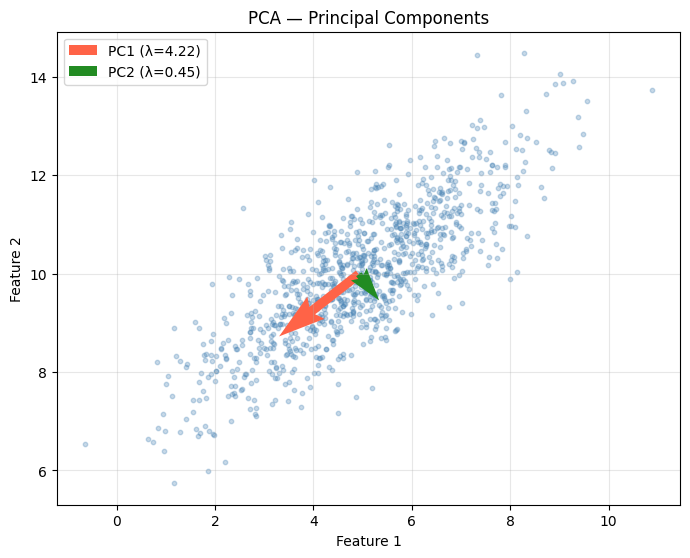

In [17]:
plot_pca(data_np, data_mean, eigenvalues, eigenvectors)

### Performance: CPU vs GPU

We benchmark PCA on increasingly large datasets. The bottleneck is the matrix multiplication `X_c^T @ X_c` for the covariance and `torch.linalg.eigh` for the eigendecomposition.

In [18]:
def pca_on_device(data, dev):
    """Run all PCA steps on *dev* and return eigenvalues, eigenvectors."""
    X = data.to(dev)
    X_c = X - X.mean(dim=0)
    C = (X_c.T @ X_c) / (X.shape[0] - 1)
    vals, vecs = torch.linalg.eigh(C)
    return vals, vecs


def benchmark_pca(n_samples, n_features, dev, n_runs=10):
    """Time PCA on *dev* and return the median wall-clock time in seconds."""
    torch.manual_seed(0)
    data_bench = torch.randn(n_samples, n_features)

    # Warm-up
    pca_on_device(data_bench, dev)
    sync(dev)

    times = []
    for _ in range(n_runs):
        sync(dev)
        t0 = time.perf_counter()
        pca_on_device(data_bench, dev)
        sync(dev)
        times.append(time.perf_counter() - t0)

    return float(np.median(times))

In [19]:
n_features = 50
pca_sizes = [1_000, 5_000, 10_000, 50_000, 100_000]

pca_cpu_times = [benchmark_pca(s, n_features, cpu_dev) for s in pca_sizes]

if gpu_dev.type != "cpu":
    pca_gpu_times = [benchmark_pca(s, n_features, gpu_dev) for s in pca_sizes]
else:
    pca_gpu_times = None
    print("No GPU available — skipping GPU benchmark.")

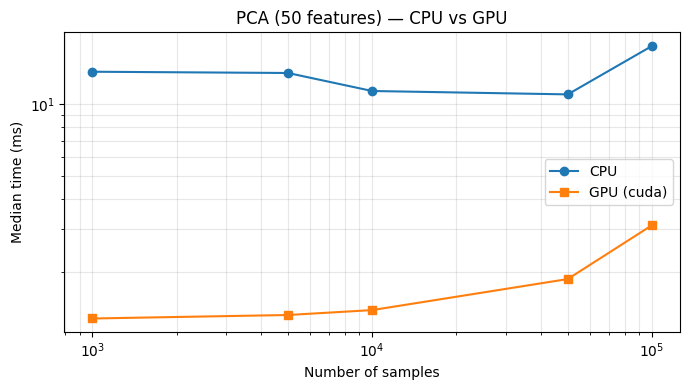

Speedup (CPU / GPU):
  n=  1,000:   10.73x
  n=  5,000:   10.25x
  n= 10,000:    8.22x
  n= 50,000:    5.90x
  n=100,000:    5.60x


In [20]:
plot_benchmark(pca_sizes, pca_cpu_times, pca_gpu_times, gpu_dev.type,
               f"PCA ({n_features} features) — CPU vs GPU")

---
## Summary

| Example | Key operations | When GPU helps |
|---|---|---|
| **Linear regression** | `linalg.lstsq`, `@` | Large number of samples |
| **PCA** | `mean`, `@` (covariance), `linalg.eigh` | Large N and/or high-dimensional data |

**Key takeaways:**
- The **same PyTorch code** runs on CPU and GPU — only the `device` argument changes.
- GPU acceleration pays off when the problem is **large enough** to offset the overhead of transferring data and launching kernels.
- Always **synchronise** (`torch.cuda.synchronize()` / `torch.xpu.synchronize()`) before measuring GPU wall-clock time.